# Apply 1550 nm laser
work around 1556.005 to dont disturb usman
- Check variation of peak 2 and 2N against fluctuations of power
- If possible, check variation of peaks 2 and 2N against variations of training parameters
- Check variation of baseline against fluctuations of power: $\int_{\lambda_1}^{\lambda_2} d\lambda Baseline(\lambda)$


In [29]:
# Load functions
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from osa import OSA
import time
import numpy as np
import matplotlib.pyplot as plt
import wshelper as wsh
import calibration
from wsapi import * 
from scipy.signal import find_peaks

#saving to latex pdf
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.preamble": r"\usepackage{amsmath}",
})

def create_connect_waveshaper():
    wsh.createWS('./WS200224_4x16.wsconfig')
    wsh.connect()

def disconnect_delete_waveshaper():
    wsh.disconnect()
    wsh.deleteWS()

def apply_waveshaper_profile(comblines, peaks, phases, channels, delta_l=0.1, sigma=0.005, plot = False):
    """
    Function to apply a waveshaper profile based on the input parameters.

    Parameters:
    - comblines: List of center frequencies for the Gaussian signals.
    - peaks: List of peak amplitudes for the Gaussian signals.
    - phases: List of phases for the Gaussian signals.
    - channels: List of channel assignments for each signal.
    - delta_l: Offset for frequency range. Default is 0.4.
    - sigma: Standard deviation for Gaussian function. Default is 0.008.
    """
    
    # Step 1: Precompute THz values for comblines and precompute bounds for each combline
    combline_thz = [wsh.nm2thz(combline) for combline in comblines] 
    rang_min = [wsh.nm2thz(combline - delta_l) for combline in comblines]
    rang_max = [wsh.nm2thz(combline + delta_l) for combline in comblines]
    
    # Step 2: Calculate the overall frequency range in THz only once
    rang = (wsh.nm2thz(min(comblines)-0.3), wsh.nm2thz(max(comblines)+0.3))
    rang = (round(rang[0], 3), round(rang[1], 3))

    # Step 3: Generate the signal profile for each combline
    signal = tuple(
        wsh.BoundFunc(
            wsh.gaussian(mu=comb_thz, peak=peak, phase=phase, sigma=sigma),
            max_r, min_r, channel
        )
        for comb_thz, peak, phase, channel, min_r, max_r 
        in zip(combline_thz, peaks, phases, channels, rang_min, rang_max)
    )
    #print(f'the peaks are: {peaks}')
    
    # Step 4: Compose the profile
    new_profile = wsh.compose_func((0, 0, 0), rang[1], rang[0], 1e-3, *signal)
    
    # Step 5: Plot the generated attenuation profile
    if plot == True:        
        plt.plot(wsh.nm2thz(new_profile[:, 0]), -new_profile[:, 1])
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Attenuation')
        plt.title('Generated Profile')
        plt.show()

    # Step 6: Apply profile to waveshaper    
    wsh.apply_profile(new_profile)



# physical_model and WaveshaperLayer.forward() need the same parameters for PAT
# coefficients, phases, normalization are for physical model
# startCombline and endCombline are for forward(), since the sweep is already stored

#TODO? add phase matching data if necessary
def physical_model(coefficients, phases, startCombline, endCombline, z=1, noise_rate=0.0, old_model=False):
    
    if noise_rate > 0:
        #noise rate is a fraction of the mean absolute value of coefficients and phases, so that the noise scales with the signal
        coefficients = coefficients + torch.randn_like(coefficients) * (noise_rate * coefficients.abs().mean())
        phases = phases + torch.randn_like(phases) * (noise_rate * phases.abs().mean())
    
    
    N = coefficients.size(0)
    intensity = None

    if old_model:
        coefficients = torch.unsqueeze(coefficients,0)
        # Prepend NaN to coefficients and phases
        nan_tensor = torch.full((coefficients.size(0), 1), float(0), dtype=coefficients.dtype, device=coefficients.device)
        C = torch.cat((nan_tensor, coefficients), dim=1)
        k = torch.cat((torch.tensor([float(0)], dtype=phases.dtype, device=phases.device), phases))
        
        intensity = torch.zeros((coefficients.size(0), 2 * N + 1), dtype=torch.float, device=C.device)

        # Use vectorized operations where possible
        m_range = [torch.full((N-1, N-1), i, device=C.device) for i in torch.arange(2, 2 * N + 1)]
        odd_m = [m for m in m_range if m[0, 0].item() % 2 == 1]
        even_m = [m for m in m_range if m[0, 0].item() % 2 == 0]

        js, ls = torch.meshgrid(torch.arange(1, N, device=C.device), torch.arange(1, N, device=C.device), indexing='ij')
        for m in odd_m:

            valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)
            j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]
            # print(f"phases {k[j]} {k[m - j]} {k[l]} {k[m - l]}")
            # print(f"exponential: {(1j * (k[j] + k[m - j] - k[l] - k[m - l]) * z)}")
            term = 4 * C[:, j] * C[:, m - j] * C[:, l] * C[:, m - l] * torch.exp(1j * (k[j] + k[m - j] - k[l] - k[m - l]) * z)
            intensity[:, m[0]] = term.sum(dim=1)

        for m in even_m:
            if m[0, 0] == 2 or m[0, 0] == 2 * N:
                intensity[:, m[0, 0]] = C[:, m[0, 0] // 2] ** 4
            else:
                valid_indices = (0 < m - js) & (m - js <= N) & (0 < m - ls) & (m - ls <= N)
                j, l, m = js[valid_indices], ls[valid_indices], m[valid_indices]
                exp_term = torch.exp(1j * (k[j] + k[m - j]) * z)
                middle_term = C[:, m // 2] ** 2 * torch.exp(1j * 2 * k[m // 2] * z)
                term1 = (2 * C[:, j] * C[:, m - j] * exp_term + middle_term).sum(dim=1)
                term2 = (2 * C[:, l] * C[:, m - l] * exp_term.conj() + middle_term.conj()).sum(dim=1)
                intensity[:, m[0]] = (term1 * term2).real

        intensity = torch.abs(intensity[:, 2:2 * N + 1])


    #alternate simulation method. Much simpler and gives far more accurate results. Might need some vectorization or to be made more compatible with torch
    else:
        # convert intensities to amplitudes
        coefficients = torch.sqrt(coefficients)
        intensity = torch.zeros((2 * N - 1), dtype=torch.float, device=coefficients.device)
        for gamma in range(1, 2 * N): #2n-1 outputs
            alpha = torch.arange(max(1, gamma-N+1), min(N, gamma) + 1, 1, device=coefficients.device)
            
            # we do a lot of redundant calculation. I briefly tried cutting the summation in half but it gives weird results
            # alpha = torch.arange(max(1, gamma-N+1), (gamma + 1) // 2 + 1, 1, device=coefficients.device)

            
            terms = coefficients[alpha - 1] * coefficients[gamma - alpha] * torch.exp(1j * (phases[alpha - 1] + phases[gamma - alpha]) * z)

            intensity[gamma - 1] = terms.sum().abs() ** 2
        
        # we need to scale the resultant intensities relative to the max if all comblines are 100% and in phase,
        # to get the same scale of values as measurement, i.e. [0, 1]
        intensity = intensity / N ** 2




    if noise_rate > 0:
        noise = torch.randn_like(intensity) * (noise_rate * intensity.abs().mean())
        #print(f"Adding intensity noise {noise}")
        intensity = torch.abs(intensity + noise)

    return intensity

import os

def create_folders(name):
    base_path = os.path.join("data_runs", name)
    stability_path = os.path.join(base_path, "stability")
    checkpoints_path = os.path.join(base_path, "checkpoints")
    traces_path = os.path.join(base_path, "traces")
    boundaries_path = os.path.join(base_path, "boundaries")

    os.makedirs(stability_path, exist_ok=True)
    os.makedirs(checkpoints_path, exist_ok=True)
    os.makedirs(traces_path, exist_ok=True)
    os.makedirs(boundaries_path, exist_ok=True)

    print(f"Folders ensured:\n- {stability_path}\n- {checkpoints_path}\n- {traces_path}\n- {boundaries_path}")


In [40]:
osa.close_connection()

Connection closed


In [30]:
SPEED_OF_LIGHT = 299792458/1
n_comblines = 50
comblines_range_A = np.arange(0, 16)
comblines_range_B = np.arange(34, 50)


# separation_comblines = 0.2
combline_freq_separation = 25 #GHZ
initial_wl = 1551.105
# initial_wl = 1543.795
initial_freq = SPEED_OF_LIGHT/initial_wl
freqs = np.arange(initial_freq, initial_freq - n_comblines * combline_freq_separation, -combline_freq_separation)

# comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
comblines = SPEED_OF_LIGHT/freqs
#get array of expected SHG wavelengths
target_freqs = np.sort(np.unique(np.add.outer(freqs, freqs)))[::-1]
targets = SPEED_OF_LIGHT/target_freqs * 1e-9# + 0.014e-9
print(f"combline wavelenths: {comblines}")
print(f"SHG wavelengths: {targets}")

combline wavelenths: [1551.105      1551.30565865 1551.50636922 1551.70713173 1551.90794621
 1552.10881267 1552.30973113 1552.51070162 1552.71172416 1552.91279875
 1553.11392543 1553.31510422 1553.51633513 1553.71761819 1553.91895341
 1554.12034082 1554.32178044 1554.52327228 1554.72481637 1554.92641272
 1555.12806137 1555.32976232 1555.5315156  1555.73332123 1555.93517922
 1556.13708961 1556.33905241 1556.54106763 1556.74313531 1556.94525546
 1557.1474281  1557.34965325 1557.55193093 1557.75426117 1557.95664398
 1558.15907938 1558.3615674  1558.56410805 1558.76670136 1558.96934734
 1559.17204602 1559.37479742 1559.57760156 1559.78045845 1559.98336812
 1560.18633059 1560.38934589 1560.59241402 1560.79553501 1560.99870889]
SHG wavelengths: [7.75552500e-07 7.75602661e-07 7.75652829e-07 7.75703004e-07
 7.75753185e-07 7.75803372e-07 7.75853566e-07 7.75903766e-07
 7.75953973e-07 7.76004186e-07 7.76054406e-07 7.76104633e-07
 7.76154866e-07 7.76205105e-07 7.76255351e-07 7.76305603e-07
 7.7635

# Intensity Calibration

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success
Applying profile...   success
Sweep complete.


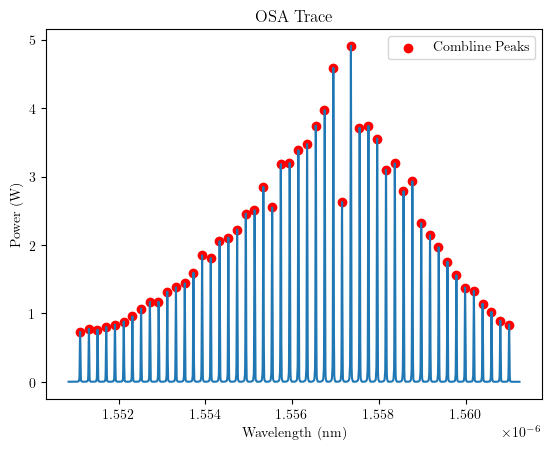

Relative combline intensities: [1.         1.06090831 1.0432139  1.09587678 1.14288837 1.20730735
 1.30825434 1.46591227 1.59759546 1.59968182 1.8032871  1.89059913
 1.96942656 2.18154038 2.53004893 2.47637524 2.81268738 2.88461671
 3.0452957  3.36588136 3.43293    3.89909215 3.48739366 4.35280547
 4.37539354 4.63146256 4.75480904 5.12419546 5.43262654 6.27904057
 3.59666151 6.71987481 5.07949954 5.11871896 4.86358647 4.2415454
 4.36722853 3.81091965 4.00841815 3.1736126  2.93096936 2.69176455
 2.40381492 2.13426035 1.8867506  1.81840027 1.56168871 1.39867768
 1.22433598 1.14636272]


In [37]:
# Connect OSA directly to waveshaper output (NOT SHG)
# Measures relative combline powers, so we can adjust peaks to get them even

host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()
peaks = np.ones(n_comblines)*.1
phases = np.zeros(n_comblines)
channels = np.ones(n_comblines)
apply_waveshaper_profile(comblines, peaks, phases, channels, plot = False, delta_l=0.05, sigma=0.005)
wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines), (np.max(comblines)-np.min(comblines))*1.05, 20, sensitivity = "high3", resolution = 0.02)

# plt.figure()
plt.plot(wavelengths, power)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (W)')
plt.title('OSA Trace')

combline_indices = [np.argmin(np.abs(wavelengths - combline*1e-9)) for combline in comblines]
# relative_combline_intensities = np.array(power)[combline_indices]
radius = (combline_indices[1] - combline_indices[0])//2

combline_intensities = np.array([
    np.array(power)[max(0, i-radius):min(len(power), i+radius)-1].max()
    for i in combline_indices
])
relative_combline_intensities = combline_intensities / np.min(combline_intensities)  # Normalize to min intensity

plt.scatter(np.array(wavelengths)[combline_indices], combline_intensities, color='red', label='Combline Peaks')
plt.legend()
plt.show()
print(f"Relative combline intensities: {relative_combline_intensities}")

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


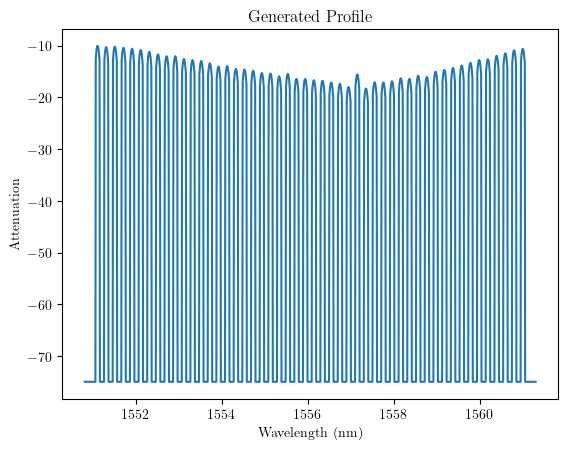

Applying profile...   success
Sweep complete.


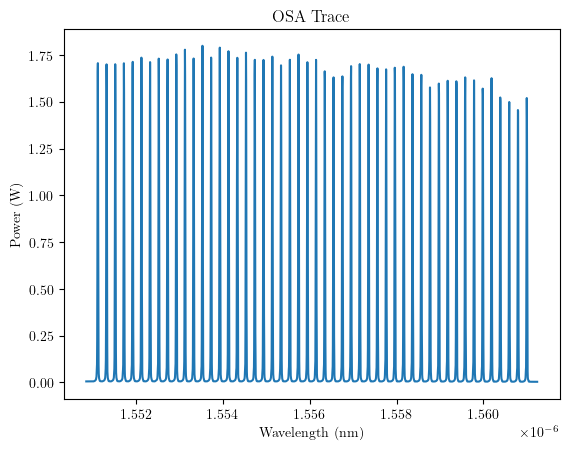

In [38]:
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()
apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phases, channels, plot = True, delta_l=0.05, sigma=0.005)
wavelengths, power = osa.perform_measurement_OSA(np.mean(comblines), (np.max(comblines)-np.min(comblines))*1.05, 20, sensitivity = "high1", resolution = 0.02)
osa.plot_trace(wavelengths, power)

# Phase and Normalization

In [ ]:
# Phase Alignment Calibration


# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()


channels = np.ones(n_comblines)
phase_offsets = np.zeros(n_comblines)

def find_phase_offset(test_combline, static_comblines, spike_wavelength, detail, center_phase=0, range=2*np.pi):
    peaks = np.zeros(n_comblines)
    peaks[test_combline] = 1
    peaks[static_comblines] = 1
    spike_index = None
    

    #looking for destructive rather than constructive terms gives greater accuracy
    lowest_intensity = np.inf
    worst_phase = 0

    for phase in np.linspace(center_phase - range/2, center_phase + range/2, detail, endpoint=(range<2*np.pi)):
        phase_offsets[test_combline] = phase
        apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phase_offsets, channels, plot = False, delta_l=0.05, sigma=0.005)
        wavelengths, power = osa.perform_measurement_OSA(spike_wavelength*1e9, 0.2, 2, sensitivity = "high2", resolution = 0.02)

        if spike_index == None: 
            spike_index = np.argmin(np.abs(wavelengths - spike_wavelength))
        spike_intensity = power[spike_index]
        print(f"Phase {phase:.2f} rad: Spike intensity = {spike_intensity}")

        if spike_intensity < lowest_intensity:
            lowest_intensity = spike_intensity
            worst_phase = phase


    if range < 2*np.pi:
        phase_offsets[test_combline] = worst_phase + np.pi
    else:
        print(f"---Searching around {worst_phase:.2f} rad---")
        find_phase_offset(test_combline, static_comblines, spike_wavelength, detail, center_phase=worst_phase, range=range/detail)


#start inclusive, end exclusive
from itertools import product
def find_phases_for_range(start, end, res, mode=2):
    
# Here we have two methods for calibrating a range of comblines. The first one ensures adjacent comblines are well-calibrated,
# but global consistency suffers as errors add up across bigger ranges. The second gives slightly better performance if stronger intraband
# SHG is needed, but phases between adjacent comblines are less consistent. 

    if mode == 1:



        for i in range(start + 2, end):
                find_phase_offset(i, [start, start+1, i-1], targets[start+i], (10 if res=="high" else 5))
                print(f"-----Best phase for combline {i} is {phase_offsets[i]}-----     {(i - start - 1) / (end - start - 2) * 100:.1f}%")



    else:


        calibrated = np.array([start, start + 1])
        steps = 0
        while calibrated.size < end - start:
            # Here we do a sort of breadth first search, using the currently calibrated comblines to calibrate all other possible
            # comblines (including non-adjacent ones) with a single step. This ensures the fewest number of steps, and thus least accumulated error, to calibrate all comblines
            steps += 1
            for reference_1, reference_2, reference_3 in product(calibrated, repeat=3):

                tester = reference_1 + reference_2 - reference_3 
                if tester not in calibrated and tester >= start and tester < end:
                    print(f"Finding {tester} with references {reference_1}, {reference_2}, {reference_3}; {steps} step(s)")
                    # target_idx = min(tester, reference_1, reference_2, reference_3) + max(tester, reference_1, reference_2, reference_3)
                    target_idx = reference_1 + reference_2
                    find_phase_offset(tester, [reference_1, reference_2, reference_3], targets[target_idx], (10 if res=="high" else 5))
                    calibrated = np.append(calibrated, tester)
                    print(f"-----Best phase for combline {tester} is {phase_offsets[tester]}-----     {(calibrated.size - 2) / (end - start - 2) * 100:.1f}%")



find_phases_for_range(comblines_range_A[0], comblines_range_A[-1]+1, res="low")
find_phases_for_range(comblines_range_B[0], comblines_range_B[-1]+1, res="low")


phase_offsets = (phase_offsets - phase_offsets[0] + np.pi) % (2 * np.pi) - np.pi
print(f"Phase offsets: {phase_offsets}")


192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success
Finding 2 with references 1, 1, 0; 1 step(s)
Applying profile...   success
Sweep complete.
Phase -3.14 rad: Spike intensity = 0.000996205932
Applying profile...   success
Sweep complete.
Phase -1.88 rad: Spike intensity = 0.00258608799
Applying profile...   success
Sweep complete.
Phase -0.63 rad: Spike intensity = 0.00566595722
Applying profile...   success
Sweep complete.
Phase 0.63 rad: Spike intensity = 0.0059141482
Applying profile...   success
Sweep complete.
Phase 1.88 rad: Spike intensity = 0.00300631019
---Searching around -3.14 rad---
Applying profile...   success
Sweep complete.
Phase -3.77 rad: Spike intensity = 0.00170040659
Applying profile...   success
Sweep complete.
Phase -3.46 rad: Spike intensity = 0.00122872113
Applying profile...   success
Sweep complete.
Phase -3.14 rad: Spike intensity = 0.001

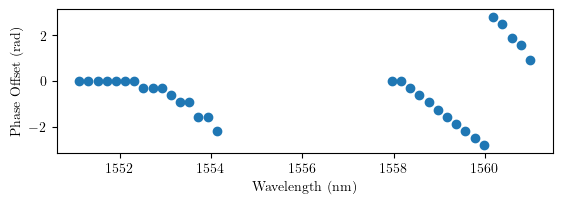

In [ ]:
plt.scatter(comblines[comblines_range_A], phase_offsets[comblines_range_A])
plt.scatter(comblines[comblines_range_B], phase_offsets[comblines_range_B], color='tab:blue')
plt.ylim(-np.pi, np.pi)
plt.ylabel('Phase Offset (rad)')
plt.xlabel('Wavelength (nm)')
plt.gca().set_aspect('0.5')
# np.savez("phase_offsets.npz", comblines=comblines, phase_offsets=phase_offsets)
# plt.savefig("phase_offsets.pdf", bbox_inches='tight')

In [63]:
phase_offsets = np.zeros(n_comblines)

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


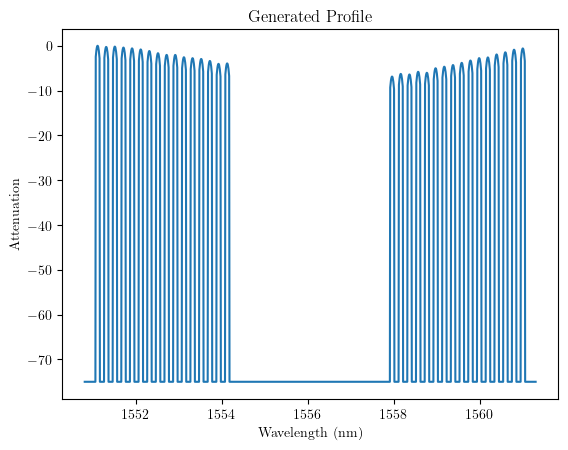

Applying profile...   success
Sweep complete.


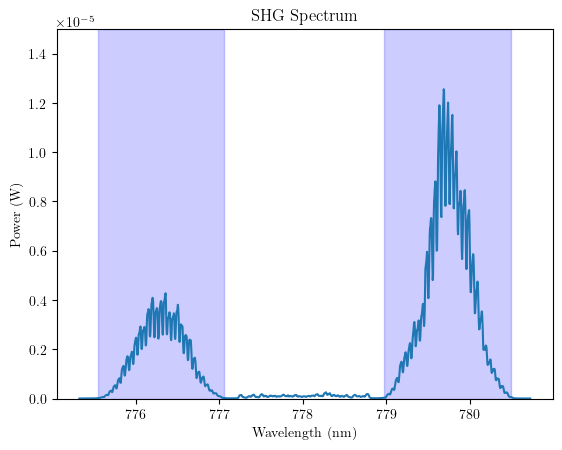

In [ ]:
# Connecting to the OSA and Waveshaper, verifying correct behaviour


# === Instantiate and connect OSA ===
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()


# print(comblines / 2)
peaks = np.zeros(n_comblines)*1
# peaks = np.array([1, 1, 1, 0, 0, 0, 0, 1, 1, 1])
peaks[comblines_range_A] = 1
peaks[comblines_range_B] = 1

phases = np.zeros(n_comblines)
# phases = np.linspace(0, np.pi, n_comblines)
channels = np.ones(n_comblines)

apply_waveshaper_profile(comblines, peaks / relative_combline_intensities, phases + phase_offsets, channels, plot = True, delta_l=0.05, sigma=0.005)



targets_A = targets[2*comblines_range_A[0]:2*comblines_range_A[-1]+1]
targets_B = targets[2*comblines_range_B[0]:2*comblines_range_B[-1]+1]
wavelengths, power = osa.perform_measurement_OSA((np.max(targets_A)+np.min(targets_A))/2*1e9, (np.max(targets_A)-np.min(targets_A))*1.1e9, 0.1, sensitivity = "high2", resolution = 0.02)
normalizationA = np.max(power)
shg_indices_A = [np.argmin(np.abs(wavelengths - t)) for t in targets_A]
# print(f"A Indices {shg_indices_A}")


plt.plot(1e9*np.array(wavelengths), 1e-3*np.array(power))#m to nm, mW to W
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (W)')
plt.title('Band A')
plt.scatter(1e9*np.array(wavelengths)[shg_indices_A], 1e-3*np.array(power)[shg_indices_A], color='red', label='Measured')
plt.legend()
plt.show()


wavelengths, power = osa.perform_measurement_OSA((np.max(targets_B)+np.min(targets_B))/2*1e9, (np.max(targets_B)-np.min(targets_B))*1.1e9, 0.1, sensitivity = "high2", resolution = 0.02)
normalizationB = np.max(power)
shg_indices_B = [np.argmin(np.abs(wavelengths - t)) for t in targets_B]
# print(f"B Indices {shg_indices_B}")


plt.plot(1e9*np.array(wavelengths), 1e-3*np.array(power))#m to nm, mW to W
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (W)')
plt.title('Band B')
plt.scatter(1e9*np.array(wavelengths)[shg_indices_B], 1e-3*np.array(power)[shg_indices_B], color='red', label='Measured')
plt.legend()
plt.show()

# sim = physical_model(torch.tensor(peaks), torch.tensor(phases), 0, 0).squeeze()
# plt.scatter(targets, sim / torch.max(sim) * np.max(power), color='black', label='Simulated')
# plt.yscale('linear')



# Training

In [17]:
# Load datasets
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import imageio  # Import the imageio library

# ===== MODEL A: make_moons dataset =====
# Step 1: Generate the make_moons dataset
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

# Step 2: Scale the dataset to the range [0, 1]
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_scaled_0_1 = (X - X_min) / (X_max - X_min)

# Step 3: Scale the dataset to the range [-1, 1]
X_scaled_neg1_1 = 2 * X_scaled_0_1 - 1

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_neg1_1, y, test_size=0.5, random_state=42)

# Step 5: Convert the data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


In [12]:
# Waveshaper layer

class WaveshaperLayer(nn.Module):
    def __init__(self, osa, comblines, channels, delta_l=0.1, sigma=0.005):
        super(WaveshaperLayer, self).__init__()
        
        self.osa = osa
        self.comblines = comblines
        self.channels = channels
        #self.normalization = normalization
        self.delta_l = delta_l
        self.sigma = sigma

        self.intensities = torch.zeros((2 * n_comblines + 1), dtype=torch.float)
        
        # Convert comblines to THz
        self.combline_thz = [wsh.nm2thz(combline) for combline in self.comblines]
        self.rang_min = [wsh.nm2thz(combline - delta_l) for combline in self.comblines]
        self.rang_max = [wsh.nm2thz(combline + delta_l) for combline in self.comblines]
        


        # Trainable phases
        # self.phases = nn.Parameter(torch.zeros(n_comblines))
        
    def performOSASweep(self, peaks, phi, normalizationA, normalizationB):
        # Generate signal profile for each combline
        max_y = np.zeros(2*n_comblines-1)
        apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)

        wavelengths, power = osa.perform_measurement_OSA((np.max(targets_A)+np.min(targets_A))/2*1e9, (np.max(targets_A)-np.min(targets_A))*1.1e9, normalizationA*1e3, sensitivity = "high2", resolution = 0.02)
        max_y[comblines_range_A[0]*2:comblines_range_A[-1]*2+1] = np.array(power)[shg_indices_A] / normalizationA

        wavelengths, power = osa.perform_measurement_OSA((np.max(targets_B)+np.min(targets_B))/2*1e9, (np.max(targets_B)-np.min(targets_B))*1.1e9, normalizationB*1e3, sensitivity = "high2", resolution = 0.02)
        max_y[comblines_range_B[0]*2:comblines_range_B[-1]*2+1] = np.array(power)[shg_indices_B] / normalizationB


        # Convert max_y (NumPy array) back to a tensor
        self.intensities = torch.tensor(max_y, dtype=torch.float32)
        #print(f"The output from OSA is {torch.unsqueeze(max_y_tensor,0)}")
        # self.intensities = torch.unsqueeze(max_y_tensor,0)



    # physical_model and WaveshaperLayer.forward() need the same parameters for PAT
    # coefficients, phases, normalization are for physical model
    # startCombline and endCombline are for forward(), since the sweep is already stored

    def forward(self, peaks, phi, startCombline, endCombline):    
        # Return sliced tensor of intensities, from 2*startCombline to 2*endCombline inclusive
        # return self.intensities[:, 2*startCombline:2*endCombline+1]
        return self.intensities[2*startCombline:2*endCombline+1]
    

In [13]:
from pat import make_pat_func
host = '192.168.10.85'  # OSA IP address
port = 10001            # OSA port number
osa = OSA(host, port)
osa.connect()
response = osa.autenticate()
create_connect_waveshaper()

# Create a Model
# comblines = np.arange(initial_wl, initial_wl + n_comblines * separation_comblines, separation_comblines)
channels = np.ones(n_comblines)

# Create the layer and pass input peaks
layer = WaveshaperLayer(osa, comblines=comblines, channels=channels)

#this code is used to construct the PAT functions
#pat_implementation = make_pat_func(physical_model, physical_model)




class Dual_Physical_NN_SHG(nn.Module):
    #TODO this is a lot of ugly repeated code, because we have all the parameters and steps for both
    #       models packed together in a joint model (intermediate layer data from both models is needed for OSA, which is ugly or impossible to sync between discrete models)
    #       In the future when we want to do this for >2 models, it's probably best to do all this with arrays or tensors or something we can iterate through for properly generic code
    #       Or, if we're training one model but running multiple batches simultaneously, we can just have one set of parameters
    def __init__(self, AstartCombline, AendCombline, BstartCombline, BendCombline, noise_rate=0.0):
        super(Dual_Physical_NN_SHG, self).__init__()

        if AendCombline - AstartCombline != BendCombline - BstartCombline:
            raise ValueError("Bands must be the same size.")


        hidden_dim_1 = (AendCombline - AstartCombline) + 1
        # hidden_dim_2 = 2 * hidden_dim_1 - 1

        self.fc1 = nn.Linear(X_train.size(1), hidden_dim_1)

        self.phases_1 = nn.Parameter(torch.randn(hidden_dim_1))
        # self.Aphases_2 = nn.Parameter(torch.randn(A_hidden_dim_2))

        self.ln = nn.LayerNorm(2*hidden_dim_1-1)

        # self.alpha = nn.Parameter(torch.zeros(2*hidden_dim_1-1))
        # self.bias = nn.Parameter(torch.zeros(1))
        self.fc2 = nn.Linear(2 * hidden_dim_1 - 1, 1)

        # 0 indexed, inclusive on both ends
        self.AstartCombline = AstartCombline
        self.AendCombline = AendCombline

        # 0 indexed, inclusive on both ends
        self.BstartCombline = BstartCombline
        self.BendCombline = BendCombline

        # Initialize fc layers

        nn.init.normal_(self.fc1.weight, mean=0.0, std=0.6)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=0.6)
        nn.init.constant_(self.fc2.bias, 0)

        # We need to wrap the functions that pat uses because it expects differentiable float parameters,
        # and doesn't play well with the combline indices. Could be solved by changing pat.py but i dont wanna mess with that
        def make_wrapper(func, startCombline, endCombline):
            return lambda amplitudes, phases: func(amplitudes, phases, startCombline, endCombline)
        def make_pat(startCombline, endCombline):
            # return make_pat_func(make_wrapper(layer.forward, startCombline, endCombline), make_wrapper(physical_model, startCombline, endCombline))
            return make_pat_func(make_wrapper(layer.forward, startCombline, endCombline), make_wrapper(physical_model, startCombline, endCombline))


        self.pat_layer_A1 = make_pat(AstartCombline, AendCombline)
        self.pat_layer_B1 = make_pat(BstartCombline, BendCombline)
        # self.pat_layer_A2 = make_pat(AstartCombline, AstartCombline + A_hidden_dim_2 - 1)
        # self.pat_layer_B2 = make_pat(BstartCombline, BstartCombline + B_hidden_dim_2 - 1)
    
    def forward(self, xA, xB, normalizationA, normalizationB):


        # Apply the custom PAT layer.

        if not isinstance(normalizationA, torch.Tensor):
            normalizationA = torch.tensor(normalizationA, dtype=torch.float32, device=X_train.device)
        if not isinstance(normalizationB, torch.Tensor):
            normalizationB = torch.tensor(normalizationB, dtype=torch.float32, device=X_train.device)

        xA = self.fc1(xA)
        xB = self.fc1(xB)

        # print(f"The output of fc1 {xA}, {xB}")

        
        #print(f"The input of pat {xA}, {xB}")
        Aphase = torch.where(xA < 0, torch.tensor(np.pi, device=xA.device), torch.tensor(0.0, device=xA.device))
        Bphase = torch.where(xB < 0, torch.tensor(np.pi, device=xB.device), torch.tensor(0.0, device=xB.device))


        xA = torch.abs(xA)
        xB = torch.abs(xB)

        xA = xA / xA.max().clamp(min=1e-5)
        xB = xB / xB.max().clamp(min=1e-5)

        # Construct full amplitude array for entire frequency space
        full_peaks = torch.zeros(n_comblines, dtype=xA.dtype, device=xA.device)
        full_peaks[self.AstartCombline:self.AendCombline+1] = xA
        full_peaks[self.BstartCombline:self.BendCombline+1] = xB
        
        # Construct full phases array for entire frequency space
        full_phases = torch.zeros(n_comblines, dtype=xA.dtype, device=xA.device)
        full_phases[self.AstartCombline:self.AendCombline+1] = self.phases_1*xA + Aphase
        full_phases[self.BstartCombline:self.BendCombline+1] = self.phases_1*xB + Bphase
        
        #perform SHG and OSA measurement. Results are stored internally in waveshaper layer
        layer.performOSASweep(full_peaks, full_phases, normalizationA, normalizationB)
        
        #perform PAT for both models. Forward it just retrieves the relevant slice of the OSA measurement
        xA = self.pat_layer_A1(xA, self.phases_1*xA+Aphase)
        xB = self.pat_layer_B1(xB, self.phases_1*xB+Bphase)
        # print(f"The output from pat 1 is {xA}, {xB}, normA {normalizationA}, normB {normalizationB}")

        # ==== PAT Layer 2 ====
        
        # Construct full amplitude array for entire frequency space
        # full_peaks = torch.zeros(n_comblines, dtype=xA.dtype, device=xA.device)
        # full_peaks[self.AstartCombline:self.AstartCombline+xA.size(0)] = xA
        # full_peaks[self.BstartCombline:self.BstartCombline+xA.size(0)] = xB
        
        # # Construct full phases array for entire frequency space
        # full_phases = torch.zeros(n_comblines, dtype=xA.dtype, device=xA.device)
        # full_phases[self.AstartCombline:self.AstartCombline+xA.size(0)] = self.Aphases_2*xA
        # full_phases[self.BstartCombline:self.BstartCombline+xB.size(0)] = self.Bphases_2*xB
        
        # #perform SHG and OSA measurement. Results are stored internally in waveshaper layer
        # layer.performOSASweep(full_peaks, full_phases, normalization)
        
        # #perform PAT for both models. Forward it just retrieves the relevant slice of the OSA measurement
        # outA = self.pat_layer_A2(xA, self.Aphases_2*xA)[:2*xA.size(0)-1]
        # outB = self.pat_layer_B2(xB, self.Bphases_2*xB)[:2*xB.size(0)-1]
        # print(f"The output from pat 2 is {outA}, {outB}, norm {normalization}")




        outA = self.ln(xA) 
        outB = self.ln(xB)
        # Final linear transformation.
        
        outA = self.fc2(outA)
        outB = self.fc2(outB)

        return outA, outB

    def parameters(self):

        return [self.phases_1] + list(self.fc1.parameters()) + list(self.ln.parameters()) + list(self.fc2.parameters())



    # def parameters_B(self):        return [self.Balpha, self.Bbias, self.Bphases_1, self.Bphases_2] + list(self.Bfc.parameters()) + list(self.Bln.parameters())

192.168.10.85 is reachable, Connected to OSA
Successfully login!
Creating waveshaper...   duplicate name, instance name already exist.
Connecting to waveshaper...   success


In [113]:
print(normalizationA, normalizationB)

2.28597984e-05 8.02449841e-06


Folders ensured:
- data_runs\experiment_batching_05\stability
- data_runs\experiment_batching_05\checkpoints
- data_runs\experiment_batching_05\traces
- data_runs\experiment_batching_05\boundaries


C:\Users\jacka\AppData\Local\Temp\ipykernel_30324\3435391344.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 0.0; the output A is tensor([3.3489], grad_fn=<ViewBackward0>)
The train binary B is 0.0; the output B is tensor([5.2393], grad_fn=<ViewBackward0>)
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 0.0; the output A is tensor([1.6766], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([4.1347], grad_fn=<ViewBackward0>)
...5%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 0.0; the output A is tensor([3.7923], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([-1.9779], grad_fn=<ViewBackward0>)
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 0.0; the output A is tensor([-1.3197], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([-0.7885], grad_fn=<ViewBackward0>)
...11%
Applying profile...   success
Sweep complete

C:\Users\jacka\AppData\Local\Temp\ipykernel_30324\3435391344.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 0.0; the output A is tensor([-5.9674], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([5.8381], grad_fn=<ViewBackward0>)
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 0.0; the output A is tensor([-8.1632], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([5.3243], grad_fn=<ViewBackward0>)
...5%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 1.0; the output A is tensor([5.1660], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([5.7454], grad_fn=<ViewBackward0>)
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 1.0; the output A is tensor([4.7358], grad_fn=<ViewBackward0>)
The train binary B is 0.0; the output B is tensor([-4.9520], grad_fn=<ViewBackward0>)
...11%
Applying profile...   success
Sweep complete

C:\Users\jacka\AppData\Local\Temp\ipykernel_30324\3435391344.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 0.0; the output A is tensor([-4.3239], grad_fn=<ViewBackward0>)
The train binary B is 0.0; the output B is tensor([-8.8719], grad_fn=<ViewBackward0>)
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 1.0; the output A is tensor([3.9837], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([7.2740], grad_fn=<ViewBackward0>)
...5%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 1.0; the output A is tensor([8.3075], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([9.4845], grad_fn=<ViewBackward0>)
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
The train binary A is 1.0; the output A is tensor([4.0148], grad_fn=<ViewBackward0>)
The train binary B is 1.0; the output B is tensor([6.6327], grad_fn=<ViewBackward0>)
...11%
Applying profile...   success
Sweep complete.

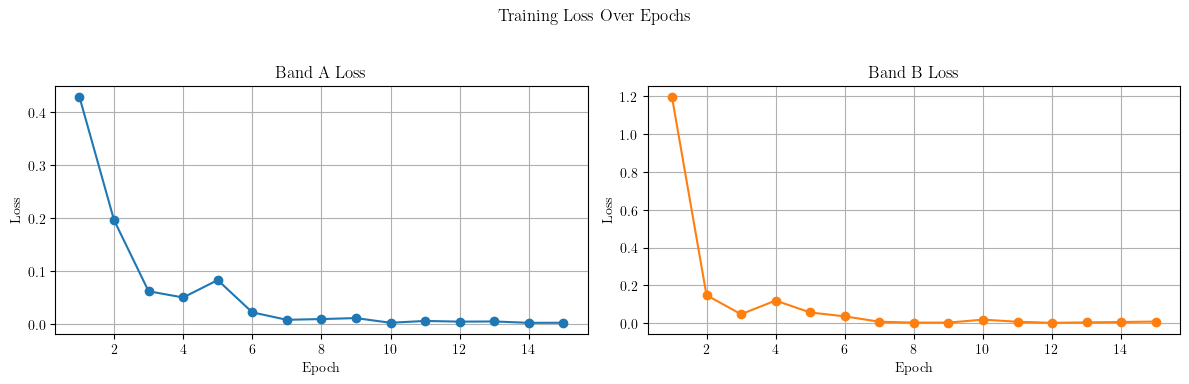

C:\Users\jacka\AppData\Local\Temp\ipykernel_30324\336061520.py:48: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
C:\Users\jacka\AppData\Local\Temp\ipykernel_30324\336061520.py:49: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, 0.2))
C:\Users\jacka\AppData\Local\Temp\ipykernel_30324\3435391344.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in th

Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying profile...   success
Sweep complete.
Sweep complete.
Applying

In [114]:
name_of_experiment = "experiment_batching_05"  # Replace with your desired folder name
create_folders(name_of_experiment)
epochs = 15

# Convert y_train_A and y_train_B to have values 0 and 1 for binary classification
import json

y_train_binary = (y_train > 0).float()
y_test_binary = (y_test > 0).float()


def save_meshgrid_and_data(xx, yy, Z, X, y, model_name):
    """
    Save the meshgrid (xx, yy), decision boundary values (Z), and dataset (X, y) to a JSON file.
    
    Parameters:
        xx (np.ndarray): Meshgrid values for x-coordinates.
        yy (np.ndarray): Meshgrid values for y-coordinates.
        Z (np.ndarray): Decision boundary values corresponding to the meshgrid.
        X (torch.Tensor): Input dataset points.
        y (torch.Tensor): Labels corresponding to dataset points.
        model_name (str): Name of the model.
    """
    data_dict = {
        "meshgrid": {
            "x": xx.tolist(),
            "y": yy.tolist(),
            "z": Z.tolist()
        },
        "data_points": {
            "X": X.tolist(),
            "y": y.tolist()
        }
    }

    filename=f"./data_runs/{name_of_experiment}/meshgrid_data_{model_name}.json"

    with open(filename, "w") as f:
        json.dump(data_dict, f, indent=4)

    print(f"Meshgrid and data points saved to {filename}")

# Example usage within your function
def plot_decision_boundary(X_A, y_A, X_B, y_B, model, epoch, normalizationA, normalizationB, nameA, nameB, save_meshgrid = False):
    # Create meshgrids for both datasets
    x_min, x_max = min(X_A[:, 0].min(), X_B[:,0].min()), max(X_A[:, 0].max(), X_B[:,0].max()) + 0.2
    y_min, y_max = min(X_A[:, 1].min(), X_B[:,1].min()), max(X_A[:, 1].max(), X_B[:,1].max()) + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                             np.arange(y_min, y_max, 0.2))
    

    
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    

    Z_A = np.empty(grid_tensor.shape[0])
    Z_B = np.empty(grid_tensor.shape[0])
    
    with torch.no_grad():
        # Evaluate both models together on their respective grids
        for point_idx in range(grid_tensor.shape[0]):
            out_A, out_B = model(grid_tensor[point_idx], grid_tensor[point_idx], normalizationA, normalizationB)
            z_value_A = torch.tanh(out_A)
            z_value_B = torch.tanh(out_B)
            Z_A[point_idx] = z_value_A.item()
            Z_B[point_idx] = z_value_B.item()
        
    Z_A = Z_A.reshape(xx.shape)
    Z_B = Z_B.reshape(xx.shape)

    # Save meshgrid and data points for both models
    if save_meshgrid:
        save_meshgrid_and_data(xx, yy, Z_A, X_A, y_A, nameA)
        save_meshgrid_and_data(xx, yy, Z_B, X_B, y_B, nameB)
    
    z_min = min(Z_A.min(), Z_B.min())
    z_max = max(Z_A.max(), Z_B.max())
    # Shared contour levels
    levels = np.linspace(z_min, z_max, 10)

    # Plotting with subplots - both models side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    
    # Plot Model A (Make Moons)
    cf1 = ax1.contourf(xx, yy, Z_A, levels=levels,alpha=0.8, cmap=plt.cm.Spectral)
    ax1.scatter(X_A[:, 0], X_A[:, 1], c=y_A, edgecolors='k', cmap=plt.cm.Spectral)
    ax1.set_title(f'{nameA} - Epoch {epoch}')
    
    # Plot Model B (Make Circles)
    ax2.contourf(xx, yy, Z_B, levels=levels,alpha=0.8, cmap=plt.cm.Spectral)
    ax2.scatter(X_B[:, 0], X_B[:, 1], c=y_B, edgecolors='k', cmap=plt.cm.Spectral)
    ax2.set_title(f'{nameB} - Epoch {epoch}')
    cbar = fig.colorbar(
        cf1,          # either cf1 or cf2 is fine since levels are identical
        ax=[ax1, ax2],
        shrink=0.9
        )
    cbar.set_label("tanh of model output")
    # plt.tight_layout()
    plt.savefig(f'./data_runs/{name_of_experiment}/boundaries/boundary_{epoch}.png')
    plt.close()

def train(model, X_train_A, X_train_B, y_train_binary_A, y_train_binary_B, optimizer, epoch, loss_history_A, loss_history_B, normalizationA, normalizationB):
    if X_train_A.shape[0] != X_train_B.shape[0]:
        raise ValueError("Training datasets A and B must have the same number of samples.")
    model.train()
    epoch_loss_A = 0
    epoch_loss_B = 0
    for data in range(X_train_A.shape[0]):
        optimizer.zero_grad()
        
        # Train both models
        output_A, output_B = model(X_train_A[data], X_train_B[data], normalizationA, normalizationB)
        # osa.save_trace(filename=f"./data_runs/{name_of_experiment}/traces/trace_data_{epoch}_{data}.csv")
        #osa.save_image('data3', f'trace_data_{epoch}_{data}_paper')
        print(f'The train binary A is {y_train_binary_A[data]}; the output A is {output_A}')
        print(f'The train binary B is {y_train_binary_B[data]}; the output B is {output_B}')
        loss_A = criterion(output_A, y_train_binary_A[data].unsqueeze(0))
        loss_B = criterion(output_B, y_train_binary_B[data].unsqueeze(0))
        loss = loss_A + loss_B
        loss.backward()
        optimizer.step()
        # optimizer_B.step()
        epoch_loss_A += loss_A.item()
        epoch_loss_B += loss_B.item()
        print(f"...{(data+1) * 100 // X_train_A.shape[0]}%")

    avg_epoch_loss_A = epoch_loss_A / X_train_A.shape[0]
    avg_epoch_loss_B = epoch_loss_B / X_train_B.shape[0]
    loss_history_A.append(avg_epoch_loss_A)  # Store the average loss in the history
    loss_history_B.append(avg_epoch_loss_B)  # Store the average loss in the history

        
def test(model, X_test_A, X_test_B, y_test_A, y_test_B, normalizationA, normalizationB):
    if X_test_A.shape[0] != X_test_B.shape[0]:
        raise ValueError("Testing datasets A and B must have the same number of samples.")
    predicted_classes_A = []
    predicted_classes_B = []
    with torch.no_grad():
        for data in range(X_test_A.shape[0]):
            y_pred_A, y_pred_B = model(X_test_A[data], X_test_B[data], normalizationA, normalizationB)
            y_pred_A = torch.sigmoid(y_pred_A)
            y_pred_B = torch.sigmoid(y_pred_B)
            predicted_classes_A.append(y_pred_A.item())
            predicted_classes_B.append(y_pred_B.item())
            print(f"...{(data+1) * 100 // X_test_A.shape[0]}%")

    # Convert to NumPy arrays
    predicted_classes_A = np.array(predicted_classes_A)
    predicted_classes_B = np.array(predicted_classes_B)
    y_test_A = y_test_A.numpy()
    y_test_B = y_test_B.numpy()

    # Calculate accuracies
    accuracy_A = accuracy_score((y_test_A > 0.5), (predicted_classes_A > 0.5))
    accuracy_B = accuracy_score((y_test_B > 0.5), (predicted_classes_B > 0.5))
    return accuracy_A, accuracy_B

interval_images = 1


# Step 4: Train the Model
#from torch.optim.lr_scheduler import LambdaLR
from torch.optim.lr_scheduler import ReduceLROnPlateau
model = Dual_Physical_NN_SHG(AstartCombline=comblines_range_A[0], AendCombline=comblines_range_A[-1], BstartCombline=comblines_range_B[0], BendCombline=comblines_range_B[-1], noise_rate=0)
#checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_init1.pth', map_location=torch.device('cpu'))
#state_dict = checkpoint['model_state_dict']
#model.load_state_dict(state_dict, strict=True)
optimizer = optim.Adam(model.parameters(), lr=2e-2)

criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy Loss with logits
#criterion = nn.MSELoss()  # Mean Squared Error Loss
#model.train()


# Create the learning rate schedulers
scheduler = ReduceLROnPlateau(optimizer, factor=0.75, patience=0, min_lr=1e-5)

import pandas as pd  # For saving data to CSV

# Initialize a dictionary to store power measurements
power_measurements = {}
for i in range(2*n_comblines-1):  
    power_measurements[f"peak{i}A"] = []
    power_measurements[f"peak{i}B"] = []
# Training loop with visualization and periodic measurements

loss_history_A = []
loss_history_B = []


for epoch in range(epochs):
    
    # randomize which points are sent to which band
    perm = torch.randperm(X_train.size(0))
    X_shuffled = X_train[perm]
    y_shuffled = y_train_binary[perm]
    mid = X_train.size(0) // 2

    train(model, X_shuffled[:mid], X_shuffled[mid:], y_shuffled[:mid], y_shuffled[mid:], optimizer, epoch, loss_history_A, loss_history_B, normalizationA, normalizationB)
    avg_loss_A = loss_history_A[-1]  # Get the most recent average loss for model A
    avg_loss_B = loss_history_B[-1]  # Get the most recent average loss for model B
    print(f"Epoch {epoch + 1}/{epochs}, Loss A: {avg_loss_A:.4f}, Loss B: {avg_loss_B:.4f}")
    

    # Uncomment for evolving boundary visualization, but it tanks the runtime. Only useful for sims
    # plot_decision_boundary(X_train_A.numpy(), y_train_A.numpy(), X_train_B.numpy(), y_train_B.numpy(), model, epoch, normalization, "Moons", "Circles")
    
    # Stop training if the loss is below the threshold
    if avg_loss_A < 0.001 and avg_loss_B < 0.001:
        print(f"Stopping early at epoch {epoch + 1} as loss < 0.001")
        break
    
    # Save checkpoint after each epoch
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_A': avg_loss_A,
        'loss_B': avg_loss_B,
    }
    if (epoch + 1) % 5 == 0:
        print("Running accuracy test...")

        perm = torch.randperm(X_test.size(0))
        X_shuffled = X_test[perm]
        y_shuffled = y_test[perm]
        mid = X_test.size(0) // 2

        #randomly select which test points go to which band
        accuracy_A, accuracy_B = test(model, X_shuffled[:mid], X_shuffled[mid:], y_shuffled[:mid], y_shuffled[mid:], normalizationA, normalizationB)

        print(f"Accuracy of model A at epoch {epoch + 1}: {accuracy_A * 100:.2f}%")
        print(f"Accuracy of model B at epoch {epoch + 1}: {accuracy_B * 100:.2f}%")
        checkpoint['accuracy_A'] = accuracy_A
        checkpoint['accuracy_B'] = accuracy_B


    torch.save(checkpoint, f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint{epoch}.pth')
    scheduler.step(avg_loss_A+avg_loss_B)
    print('Learning rate:', scheduler._last_lr)
    # Perform measurement every 10 epochs
    if (epoch + 1) % 1 == 0:
        peaks_decoupling = np.zeros(n_comblines)
        peaks_decoupling[comblines_range_A] = 1
        peaks_decoupling[comblines_range_B] = 1
        peaks_decoupling = peaks_decoupling / relative_combline_intensities

        phases_decoupling = phase_offsets
        channels_decoupling = np.ones(n_comblines)

        apply_waveshaper_profile(comblines, peaks_decoupling, phases_decoupling, channels_decoupling, plot = False)
        wav, power = osa.perform_measurement_OSA((np.max(targets_A)+np.min(targets_A))/2*1e9, (np.max(targets_A)-np.min(targets_A))*1.1e9, normalizationA*1e3, sensitivity = "high2", resolution = 0.02)
        normalizationA = np.max(power)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/stability/trace_data_{epoch}_A.csv")

        for i, index in enumerate(shg_indices_A):
            power_measurements[f"peak{i}A"].append(power[index])

        wav, power = osa.perform_measurement_OSA((np.max(targets_B)+np.min(targets_B))/2*1e9, (np.max(targets_B)-np.min(targets_B))*1.1e9, normalizationB*1e3, sensitivity = "high2", resolution = 0.02)
        normalizationB = np.max(power)
        osa.save_trace(filename=f"./data_runs/{name_of_experiment}/stability/trace_data_{epoch}_B.csv")

        for i, index in enumerate(shg_indices_B):
            power_measurements[f"peak{i}B"].append(power[index])
        # Store power at specified indices

        
        print(f"Normalization measurements taken at epoch {epoch + 1}: {normalizationA}, {normalizationB}")
        
# Save power measurements to a CSV file
df = pd.DataFrame([power_measurements])  # Convert dictionary to a DataFrame
df.to_csv(f'./data_runs/{name_of_experiment}/spectral_consistency.csv', index=False)
print("Power measurements saved to spectral_consistency.csv")

# Plot the loss over epochs for both models side by side
n_epochs = min(len(loss_history_A), len(loss_history_B))
epochs_range = range(1, n_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
ax1.plot(epochs_range, loss_history_A[:n_epochs], marker='o', color='tab:blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Band A Loss')
ax1.grid(True)

ax2.plot(epochs_range, loss_history_B[:n_epochs], marker='o', color='tab:orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Band B Loss')
ax2.grid(True)

plt.suptitle('Training Loss Over Epochs')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plot the final decision boundary for both models
perm = torch.randperm(X_test.size(0))
X_shuffled = X_test[perm]
y_shuffled = y_test[perm]
mid = X_train.size(0) // 2
plot_decision_boundary(X_shuffled[:mid], y_shuffled[:mid], X_shuffled[mid:], y_shuffled[mid:], model, epoch, normalizationA, normalizationB, "Band A", "Band B", save_meshgrid=True)



C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\2732817101.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(point[0], point[1], c='r', edgecolors='k', marker='o', cmap=plt.cm.Spectral, s=200)
C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\2732817101.py:45: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(point[0], point[1], c='b', edgecolors='k', marker='*', cmap=plt.cm.Spectral, s=200)
C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\2732817101.py:62: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(point[0], point[1], c='r', edgecolors='k', marker='o', cmap=plt.cm.Spectral, s=200)
C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\2732817101.py:60: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(point[0], point[1], c='b', edgecolors='k', marker='*', cmap=

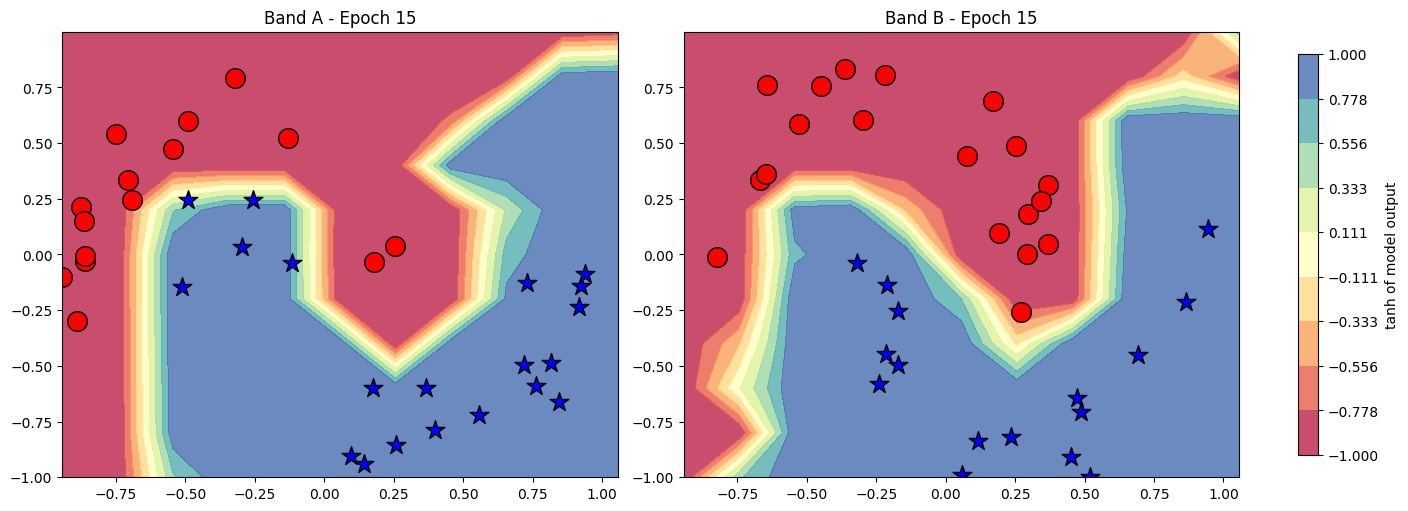

In [ ]:
#load meshgrid data and plot decision boundary


import json
import numpy as np

name_of_experiment = "experiment_batching_05"


def retrieve_meshgrid_and_data(name):
    filename = f"./data_runs/{name_of_experiment}/meshgrid_data_{name}.json"
    with open(filename, "r") as f:
        data = json.load(f)

    xx = np.array(data["meshgrid"]["x"])
    yy = np.array(data["meshgrid"]["y"])
    Z = np.array(data["meshgrid"]["z"])

    X = np.array(data["data_points"]["X"])
    y = np.array(data["data_points"]["y"])

    return (xx, yy, Z, X, y)


nameA = "Band A"
nameB = "Band B"

xx_A, yy_A, Z_A, X_A, y_A = retrieve_meshgrid_and_data(nameA)
xx_B, yy_B, Z_B, X_B, y_B = retrieve_meshgrid_and_data(nameB)

z_min = min(Z_A.min(), Z_B.min())
z_max = max(Z_A.max(), Z_B.max())
# Shared contour levels
levels = np.linspace(z_min, z_max, 10)

# Plotting with subplots - both models side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
ax1.set_xlim(xx_A.min(), xx_A.max())
ax1.set_ylim(yy_A.min(), yy_A.max())
ax2.set_xlim(xx_B.min(), xx_B.max())
ax2.set_ylim(yy_B.min(), yy_B.max())

# Plot Model A (Make Moons)
cf1 = ax1.contourf(xx_A, yy_A, Z_A, levels=levels,alpha=0.8, cmap=plt.cm.Spectral)

for idx, point in enumerate(X_A):
    if y_A[idx] == 1:
        ax1.scatter(point[0], point[1], c='b', edgecolors='k', marker='*', cmap=plt.cm.Spectral, s=200)
    else:
        ax1.scatter(point[0], point[1], c='r', edgecolors='k', marker='o', cmap=plt.cm.Spectral, s=200)


# ax1.scatter(X_A[:, 0], X_A[:, 1], c=y_A, edgecolors='k', cmap=plt.cm.Spectral)

ax1.set_title(f'{nameA} - Epoch {epoch}')

# Plot Model B (Make Circles)
ax2.contourf(xx_B, yy_B, Z_B, levels=levels,alpha=0.8, cmap=plt.cm.Spectral)

# ax2.scatter(X_B[:, 0], X_B[:, 1], c=y_B, edgecolors='k', cmap=plt.cm.Spectral)
for idx, point in enumerate(X_B):
    if y_B[idx] == 1:
        ax2.scatter(point[0], point[1], c='b', edgecolors='k', marker='*', cmap=plt.cm.Spectral, s=200)
    else:
        ax2.scatter(point[0], point[1], c='r', edgecolors='k', marker='o', cmap=plt.cm.Spectral, s=200)

ax2.set_title(f'{nameB} - Epoch {epoch}')
cbar = fig.colorbar(
    cf1,          # either cf1 or cf2 is fine since levels are identical
    ax=[ax1, ax2],
    shrink=0.9
    )
cbar.set_label("tanh of model output")
# plt.tight_layout()
plt.savefig(f"./figures/{name_of_experiment}_boundaries.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
#
# Load model and perform accuracy evaluation and decision boundary plotting
# Even after complete recoupling, pump WL change, and recalibration of intensities/phases, performance remains high
#

def save_meshgrid_and_data(xx, yy, Z, X, y, model_name):
    """
    Save the meshgrid (xx, yy), decision boundary values (Z), and dataset (X, y) to a JSON file.
    
    Parameters:
        xx (np.ndarray): Meshgrid values for x-coordinates.
        yy (np.ndarray): Meshgrid values for y-coordinates.
        Z (np.ndarray): Decision boundary values corresponding to the meshgrid.
        X (torch.Tensor): Input dataset points.
        y (torch.Tensor): Labels corresponding to dataset points.
        model_name (str): Name of the model.
    """
    data_dict = {
        "meshgrid": {
            "x": xx.tolist(),
            "y": yy.tolist(),
            "z": Z.tolist()
        },
        "data_points": {
            "X": X.tolist(),
            "y": y.tolist()
        }
    }

    filename=f"./data_runs/{name_of_experiment}/meshgrid_data_{model_name}.json"

    with open(filename, "w") as f:
        json.dump(data_dict, f, indent=4)

    print(f"Meshgrid and data points saved to {filename}")

# Example usage within your function
def plot_decision_boundary(X_A, y_A, X_B, y_B, model, epoch, normalizationA, normalizationB, nameA, nameB, save_meshgrid = False):
    # Create meshgrids for both datasets
    x_min, x_max = min(X_A[:, 0].min(), X_B[:,0].min()), max(X_A[:, 0].max(), X_B[:,0].max()) + 0.2
    y_min, y_max = min(X_A[:, 1].min(), X_B[:,1].min()), max(X_A[:, 1].max(), X_B[:,1].max()) + 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                             np.arange(y_min, y_max, 0.2))
    

    
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    

    Z_A = np.empty(grid_tensor.shape[0])
    Z_B = np.empty(grid_tensor.shape[0])
    
    with torch.no_grad():
        # Evaluate both models together on their respective grids
        for point_idx in range(grid_tensor.shape[0]):
            out_A, out_B = model(grid_tensor[point_idx], grid_tensor[point_idx], normalizationA, normalizationB)
            z_value_A = torch.tanh(out_A)
            z_value_B = torch.tanh(out_B)
            Z_A[point_idx] = z_value_A.item()
            Z_B[point_idx] = z_value_B.item()
        
    Z_A = Z_A.reshape(xx.shape)
    Z_B = Z_B.reshape(xx.shape)

    # Save meshgrid and data points for both models
    if save_meshgrid:
        save_meshgrid_and_data(xx, yy, Z_A, X_A, y_A, nameA)
        save_meshgrid_and_data(xx, yy, Z_B, X_B, y_B, nameB)
    
    z_min = min(Z_A.min(), Z_B.min())
    z_max = max(Z_A.max(), Z_B.max())
    # Shared contour levels
    levels = np.linspace(z_min, z_max, 10)

    # Plotting with subplots - both models side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    
    # Plot Model A (Make Moons)
    cf1 = ax1.contourf(xx, yy, Z_A, levels=levels,alpha=0.8, cmap=plt.cm.Spectral)
    ax1.scatter(X_A[:, 0], X_A[:, 1], c=y_A, edgecolors='k', cmap=plt.cm.Spectral)
    ax1.set_title(f'{nameA} - Epoch {epoch}')
    
    # Plot Model B (Make Circles)
    ax2.contourf(xx, yy, Z_B, levels=levels,alpha=0.8, cmap=plt.cm.Spectral)
    ax2.scatter(X_B[:, 0], X_B[:, 1], c=y_B, edgecolors='k', cmap=plt.cm.Spectral)
    ax2.set_title(f'{nameB} - Epoch {epoch}')
    cbar = fig.colorbar(
        cf1,          # either cf1 or cf2 is fine since levels are identical
        ax=[ax1, ax2],
        shrink=0.9
        )
    cbar.set_label("tanh of model output")
    # plt.tight_layout()
    plt.savefig(f'./data_runs/{name_of_experiment}/boundaries/boundary_{epoch}.png')
    plt.close()
def test(model, X_test_A, X_test_B, y_test_A, y_test_B, normalizationA, normalizationB):
    if X_test_A.shape[0] != X_test_B.shape[0]:
        raise ValueError("Testing datasets A and B must have the same number of samples.")
    predicted_classes_A = []
    predicted_classes_B = []
    with torch.no_grad():
        for data in range(X_test_A.shape[0]):
            y_pred_A, y_pred_B = model(X_test_A[data], X_test_B[data], normalizationA, normalizationB)
            y_pred_A = torch.sigmoid(y_pred_A)
            y_pred_B = torch.sigmoid(y_pred_B)
            predicted_classes_A.append(y_pred_A.item())
            predicted_classes_B.append(y_pred_B.item())
            print(f"Class: {y_test_A[data]} Predicted: {y_pred_A.item():.4f}")
            print(f"Class: {y_test_B[data]} Predicted: {y_pred_B.item():.4f}")
            print(f"...{(data+1) * 100 // X_test_A.shape[0]}%")

    # Convert to NumPy arrays
    predicted_classes_A = np.array(predicted_classes_A)
    predicted_classes_B = np.array(predicted_classes_B)
    y_test_A = y_test_A.numpy()
    y_test_B = y_test_B.numpy()

    # Calculate accuracies
    accuracy_A = accuracy_score((y_test_A > 0.5), (predicted_classes_A > 0.5))
    accuracy_B = accuracy_score((y_test_B > 0.5), (predicted_classes_B > 0.5))
    return accuracy_A, accuracy_B


name_of_experiment = "experiment_batching_05"

# Load the model from the checkpoint
model = Dual_Physical_NN_SHG(AstartCombline=comblines_range_A[0], AendCombline=comblines_range_A[-1], BstartCombline=comblines_range_B[0], BendCombline=comblines_range_B[-1], noise_rate=0)
checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint14.pth', map_location=torch.device('cpu'))
state_dict = checkpoint['model_state_dict']
model.load_state_dict(state_dict, strict=True)


perm = torch.randperm(X_test.size(0))
X_shuffled = X_test[perm]
y_shuffled = y_test[perm]
mid = X_test.size(0) // 2

accuracy_A, accuracy_B = test(model, X_shuffled[:mid], X_shuffled[mid:], y_shuffled[:mid], y_shuffled[mid:], normalizationA, normalizationB)
print(f"Accuracy of model A: {accuracy_A * 100:.2f}%")
print(f"Accuracy of model B: {accuracy_B * 100:.2f}%")

# plot_decision_boundary(X_shuffled[:mid], y_shuffled[:mid], X_shuffled[mid:], y_shuffled[mid:], model, 1000, normalizationA, normalizationB, "Band A-Delayed", "Band B-Delayed", save_meshgrid=True)


C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3435391344.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  apply_waveshaper_profile(self.comblines, peaks.detach() / relative_combline_intensities, phi.detach(), self.channels)


Applying profile...   success
Sweep complete.
Sweep complete.
Class: 0.0 Predicted: 2.7580501409829594e-05
Class: 0.0 Predicted: 0.01179335918277502
...2%
Applying profile...   success
Sweep complete.
Sweep complete.
Class: 0.0 Predicted: 0.6363030076026917
Class: 1.0 Predicted: 0.9966206550598145
...4%
Applying profile...   success
Sweep complete.
Sweep complete.
Class: 1.0 Predicted: 0.9994747042655945
Class: 0.0 Predicted: 0.00021365539578255266
...6%
Applying profile...   success
Sweep complete.
Sweep complete.
Class: 0.0 Predicted: 0.00020224973559379578
Class: 0.0 Predicted: 1.990182136069052e-05
...8%
Applying profile...   success
Sweep complete.
Sweep complete.
Class: 0.0 Predicted: 0.0002715191221795976
Class: 1.0 Predicted: 0.9996991157531738
...10%
Applying profile...   success
Sweep complete.
Sweep complete.
Class: 0.0 Predicted: 0.007410618010908365
Class: 0.0 Predicted: 0.00011169142089784145
...12%
Applying profile...   success
Sweep complete.
Sweep complete.
Class: 1.0 

Accuracy A not found in model_checkpoint0.pth
Accuracy B not found in model_checkpoint0.pth
Accuracy A not found in model_checkpoint1.pth
Accuracy B not found in model_checkpoint1.pth
Accuracy A not found in model_checkpoint2.pth
Accuracy B not found in model_checkpoint2.pth
Accuracy A not found in model_checkpoint3.pth
Accuracy B not found in model_checkpoint3.pth
Accuracy A not found in model_checkpoint5.pth
Accuracy B not found in model_checkpoint5.pth
Accuracy A not found in model_checkpoint6.pth
Accuracy B not found in model_checkpoint6.pth
Accuracy A not found in model_checkpoint7.pth
Accuracy B not found in model_checkpoint7.pth
Accuracy A not found in model_checkpoint8.pth
Accuracy B not found in model_checkpoint8.pth
Accuracy A not found in model_checkpoint10.pth
Accuracy B not found in model_checkpoint10.pth
Accuracy A not found in model_checkpoint11.pth
Accuracy B not found in model_checkpoint11.pth
Accuracy A not found in model_checkpoint12.pth
Accuracy B not found in model

C:\Users\jacka\AppData\Local\Temp\ipykernel_25524\3389284404.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


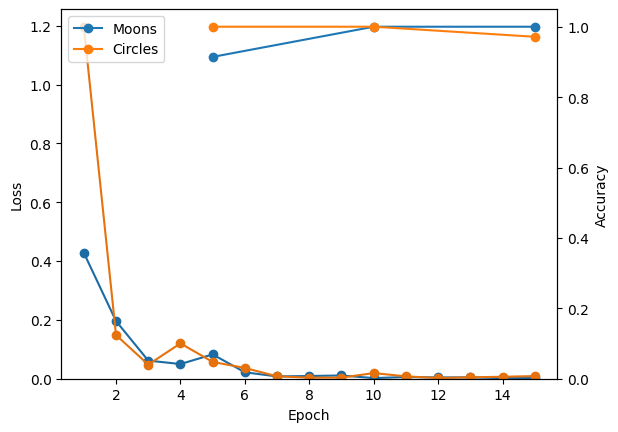

In [ ]:
#Load accuracy and loss data from checkpoint and plot

import torch
import os
import matplotlib.colors as mcolors
import numpy as np

def darken(color, factor=0.9):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb * factor)

base_a = "tab:blue"
base_b = "tab:orange"

name_of_experiment = 'experiment_batching_05'
# Path to the directory containing the files
directory = f"./data_runs/{name_of_experiment}/checkpoints"

# Get a sorted list of checkpoint files in numerical order
file_list = sorted(
    [f for f in os.listdir(directory) if f.startswith("model_checkpoint") and f.endswith(".pth")],
    key=lambda x: int(x.split("checkpoint")[1].split(".pth")[0])
)
# Initialize a list to store the losses
lossesA = []
lossesB = []
accuraciesA = []
accuraciesB = []

# Loop through all the checkpoint files in the directory
for filename in file_list:
    if filename.endswith('.pth'):
        # Construct the full file path
        file_path = os.path.join(directory, filename)
        
        # Load the checkpoint
        checkpoint = torch.load(file_path)
        epoch = checkpoint['epoch'] + 1
        # Extract the loss value (assuming it is stored with the key 'loss')
        if 'loss_A' in checkpoint:
            loss = checkpoint['loss_A']
            lossesA.append((filename, loss, epoch))
        else:
            print(f"LossA not found in {filename}")
        if 'loss_B' in checkpoint:
            loss = checkpoint['loss_B']
            lossesB.append((filename, loss, epoch))
        else:
            print(f"LossB not found in {filename}")

        if 'accuracy_A' in checkpoint:
            accuracy = checkpoint['accuracy_A']
            accuraciesA.append((filename, accuracy, epoch))
        else:
            print(f"Accuracy A not found in {filename}")

        if 'accuracy_B' in checkpoint:
            accuracy = checkpoint['accuracy_B']
            accuraciesB.append((filename, accuracy, epoch))
        else:
            print(f"Accuracy B not found in {filename}")

# Print the extracted losses
for filename, loss, _ in lossesA:
    print(f"{filename}: LossA = {loss}")
for filename, loss, _ in lossesB:
    print(f"{filename}: LossB = {loss}")

# Print the extracted losses
for filename, accuracy, _ in accuraciesA:
    print(f"{filename}: Accuracy = {accuracy}")
for filename, accuracy, _ in accuraciesB:
    print(f"{filename}: Accuracy = {accuracy}")

# Optional: Plot the losses for visualization
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()


# Extracting just the loss values for plotting
loss_values = [(epoch, loss) for _, loss, epoch in lossesA]
ax1.plot(*zip(*loss_values), marker='o', color=darken(base_a))
loss_values = [(epoch, loss) for _, loss, epoch in lossesB]
ax1.plot(*zip(*loss_values), marker='o', color=darken(base_b))
plt.legend()
ax1.set_ylim(bottom=0)
ax1.set_xlabel("Epoch")
# plt.title("Loss vs Epoch")
# plt.ylabel("Loss")
ax1.set_ylabel("Loss")
# plt.grid(True)

# plt.savefig(f"./figures/{name_of_experiment}_losses.pdf", format="pdf", bbox_inches="tight")
# plt.show()


# Extracting just the loss values for plotting
accuracy_values = [(epoch, accuracy) for _, accuracy, epoch in accuraciesA]
ax2.plot(*zip(*accuracy_values), marker='o', label='Moons')
accuracy_values = [(epoch, accuracy) for _, accuracy, epoch in accuraciesB]
ax2.plot(*zip(*accuracy_values), marker='o', label='Circles')
plt.legend()
# ax2.xlim(left=1)
ax2.set_ylim(top=1.05, bottom=0)
# plt.title("Accuracy vs Epoch")
# plt.xlabel("Epoch")
ax2.set_ylabel("Accuracy")

# plt.grid(True)

# plt.savefig(f"./figures/{name_of_experiment}_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
# === Disconnect ===
disconnect_delete_waveshaper()
osa.close_connection()

Disconnecting from waveshaper...   success
Deliting waveshaper...   success
Connection closed


In [ ]:
import torch

# Load the .pth file
checkpoint = torch.load(f'./data_runs/{name_of_experiment}/checkpoints/model_checkpoint10.pth', map_location=torch.device('cpu'))
print(type(checkpoint))
checkpoint['model_state_dict']


<class 'dict'>


C:\Users\ws-server\AppData\Local\Temp\ipykernel_10156\2629051906.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'./data_runs/{name_of_experimen

OrderedDict([('alpha',
              tensor([-0.0125, -0.0176, -0.0232, -0.0183, -0.0027, -0.0443, -0.0145, -0.2646,
                      -0.0248, -0.5596,  0.1471, -0.1097, -0.1492, -0.1778,  0.0481,  0.0646,
                       0.2945,  0.0266,  0.3211,  0.1230, -1.1382, -0.1040,  0.2167,  0.2027,
                       0.2118, -0.0827,  0.0591,  0.0096,  0.0081])),
             ('bias', tensor([-0.0108])),
             ('phases',
              tensor([-0.1714,  0.0290, -0.0602,  0.3793, -0.0110,  0.0763,  0.0540, -0.0922,
                      -0.6505,  0.1497,  0.5390,  3.1698, -1.0237, -0.3132,  0.2370])),
             ('fc.weight',
              tensor([[ 2.6431, -0.6957],
                      [ 2.9011, -0.4326],
                      [ 2.1585, -0.7287],
                      [ 1.7431,  0.8088],
                      [ 2.4911, -1.3772],
                      [-2.8624,  0.3889],
                      [ 2.2417,  0.9271],
                      [ 2.9565, -1.5018],
              